In [ ]:
import torch
import numpy as np
from resnet_18.graspy_resnet18 import GraSpyResNet18
from zevin_coughlin_net.zevin_coughlin_net import ZevinCoughlinNet
from zevin_coughlin_net.data_preprocessing import preprocessData
import warnings
warnings.filterwarnings('ignore')

In [ ]:
num_classes = 22
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_folder = "resnet_18"
weight_name = "best_resnet18.pt"
dataset_path = "./gravity-spy-dataset/"

training_loader, validation_loader, testing_loader = preprocessData(dataset_path)

if weights_folder == "resnet_18":
    model = GraSpyResNet18(num_classes=num_classes)
elif weights_folder == "ZevinCoughlinNet":
    model = ZevinCoughlinNet(num_classes=num_classes)

model.load_state_dict(
    torch.load(weights_folder + "/" + weight_name , map_location=device)
);

model = model.to(device);
model.eval();

In [112]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in testing_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)


In [113]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    all_labels,
    all_preds,
    target_names=testing_loader.dataset.classes
))

                     precision    recall  f1-score   support

          1080Lines       0.96      0.89      0.92       200
        1400Ripples       0.71      1.00      0.83        36
     Air_Compressor       1.00      0.97      0.99        36
               Blip       0.96      0.97      0.97      1092
              Chirp       0.97      0.75      0.85        40
     Extremely_Loud       0.94      0.98      0.96       256
              Helix       0.99      1.00      1.00       168
           Koi_Fish       0.97      0.99      0.98       408
   Light_Modulation       0.96      0.95      0.95       312
Low_Frequency_Burst       0.93      0.94      0.94       360
Low_Frequency_Lines       0.89      0.91      0.90       264
          No_Glitch       0.70      0.67      0.68        84
  None_of_the_Above       0.63      0.75      0.69        44
       Paired_Doves       1.00      0.50      0.67        16
         Power_Line       0.96      0.98      0.97       272
    Repeating_Blips    

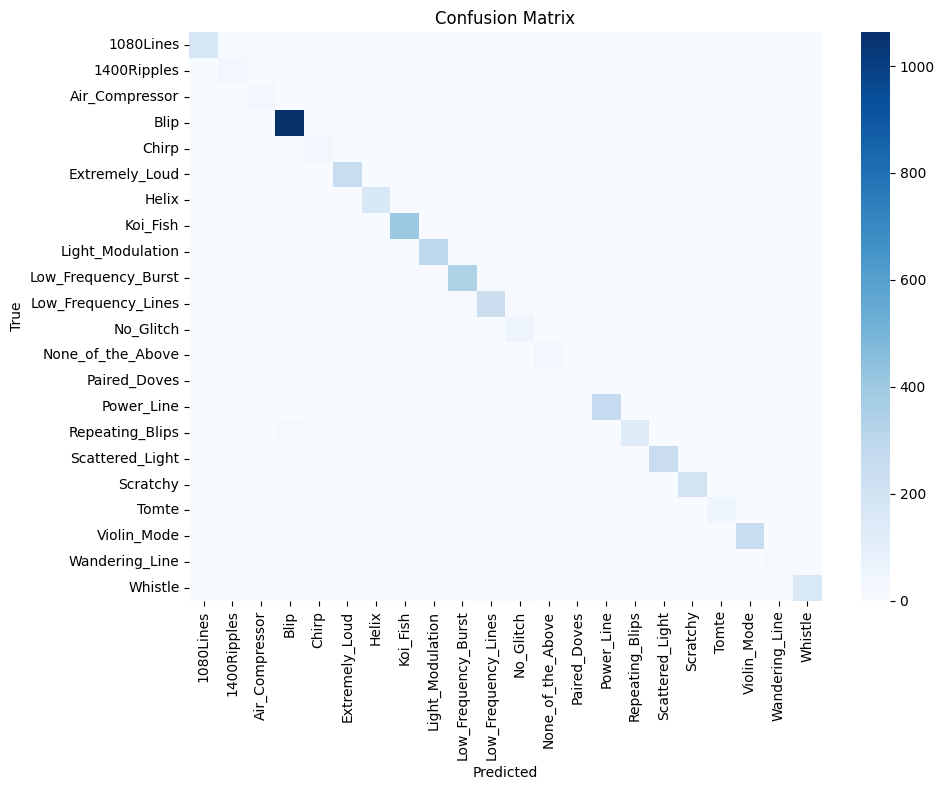

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    xticklabels=testing_loader.dataset.classes,
    yticklabels=testing_loader.dataset.classes,
    cmap="Blues",
    norm=None
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [115]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Macro F1: 0.8958070995354084
Weighted F1: 0.943803979552554


In [116]:
from pathlib import Path

directory_path = Path('./ResNet18')  # Use '.' for the current directory

for file_path in directory_path.iterdir():
    if file_path.is_file() and ("model_20251223_211357" in str(file_path)):
        model.load_state_dict(
            torch.load(str(file_path) , map_location=device));

        model = model.to(device)
        model.eval()

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in testing_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)

                all_preds.append(preds.cpu().numpy())
                all_labels.append(labels.cpu().numpy())

        all_preds = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)
        
        macro_f1 = f1_score(all_labels, all_preds, average="macro")
        weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
        
        print("File name:", str(file_path), "Macro F1:", macro_f1, "Weighted F1:", weighted_f1)